# Module 1: Single Instrument Pricing — Expanded Verification

A deep dive into the fixed-rate bond pricing engine. We verify against textbook examples,
visualise the price-yield relationship, inspect cash flows, and explore how coupon rate,
maturity, and frequency affect bond prices.

In [1]:
# ruff: noqa: E402
import sys
import warnings
from datetime import date, timedelta

sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np

from src.instruments.bond import Bond
from src.instruments.pricing import price
from src.instruments.ytm_solver import (
    TOLERANCE,
    dv01_approx,
    price_diff,
    ytm_solver,
)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10
print("All imports OK — ready to explore.")

All imports OK — ready to explore.


---
## 1. Bond Anatomy

A `Bond` is the fundamental instrument. Let's inspect its properties.

In [2]:
b = Bond(face_value=100, coupon_rate=0.05, maturity=3.0, freq=2)
print(f"{b!r}\n")
print(f"  Face value:       {b.face_value}")
print(f"  Coupon rate:      {b.coupon_rate * 100:.2f}%")
print(f"  Maturity:         {b.maturity} years")
print(f"  Frequency:        {b.freq} x / year")
print(f"  Total periods:    {b.periods}  (= maturity × freq)")
print(f"  Coupon payment:   {b.coupon_payment}  (= face × coupon / freq)")

Bond(face_value=100, coupon_rate=0.05, maturity=3.0, freq=2)

  Face value:       100
  Coupon rate:      5.00%
  Maturity:         3.0 years
  Frequency:        2 x / year
  Total periods:    6  (= maturity × freq)
  Coupon payment:   2.5  (= face × coupon / freq)


### Validation
The `Bond` rejects nonsensical inputs at construction time.

In [3]:
bad_cases = [
    ("negative face", lambda: Bond(-100, 0.05, 3.0)),
    ("negative coupon", lambda: Bond(100, -0.01, 3.0)),
    ("zero maturity", lambda: Bond(100, 0.05, 0)),
    ("invalid freq (3)", lambda: Bond(100, 0.05, 3.0, freq=3)),
    ("invalid freq (0)", lambda: Bond(100, 0.05, 3.0, freq=0)),
]

for label, case in bad_cases:
    try:
        case()
        print(f"  ✗ {label}: should have raised!")
    except ValueError as e:
        print(f"  ✓ {label}: {e}")

  ✓ negative face: face_value must be positive
  ✓ negative coupon: coupon_rate must be non-negative
  ✓ zero maturity: maturity must be positive
  ✓ invalid freq (3): freq must be 1, 2, 4, or 12
  ✓ invalid freq (0): freq must be 1, 2, 4, or 12


---
## 2. Pricing Formula

The price of a fixed-rate bond is the sum of the present values of all future
cash flows:

$$
P = \sum_{t=1}^{T \times m} \frac{F \cdot C \,/\, m}{(1 + y \,/\, m)^t}
    + \frac{F}{(1 + y \,/\, m)^{T \times m}}
$$

The first term sums the present values of all coupon payments, while the
second term is the present value of the face value (principal) returned at
maturity. Each cash flow is discounted by the per-period yield $y/m$,
raised to the power of the number of periods until that cash flow is
received.

| Symbol | Meaning |
|--------|---------|
| $F$ | Face value (principal) |
| $C$ | Annual coupon rate as a decimal (e.g. 0.05 for 5%) |
| $F \cdot C / m$ | Dollar coupon payment per period |
| $T$ | Years to maturity |
| $m$ | Coupon payments per year |
| $y$ | Market yield (YTM, decimal) |

Let's unpack this by looking at the individual cash flows.

In [4]:
def cash_flow_schedule(bond: Bond, yield_rate: float):
    """Return array of periods, cash flows, discount factors, and PV."""
    r = yield_rate / bond.freq
    t = np.arange(1, bond.periods + 1)
    cf = np.full(bond.periods, bond.coupon_payment)
    cf[-1] += bond.face_value  # final payment includes principal
    df = (1 + r) ** -t  # discount factors
    pv = cf * df
    return t, cf, df, pv


b = Bond(100, 0.05, 3.0, 2)
t, cf, df, pv = cash_flow_schedule(b, 0.04)

print(f"Bond: 3-year, 5% semi-annual, yield = 4%  |  Price = {pv.sum():.6f}\n")
print("  Period   Cash Flow   Discount Factor   Present Value")
print("  ------   ---------   ---------------   -------------")
for i in range(len(t)):
    print(f"  {t[i]:>5.0f}   {cf[i]:>9.2f}   {df[i]:>15.6f}   {pv[i]:>13.6f}")
print(f"  {'':->50}")
print(f"  {'Total':>27}   {pv.sum():>13.6f}")

Bond: 3-year, 5% semi-annual, yield = 4%  |  Price = 102.800715

  Period   Cash Flow   Discount Factor   Present Value
  ------   ---------   ---------------   -------------
      1        2.50          0.980392        2.450980
      2        2.50          0.961169        2.402922
      3        2.50          0.942322        2.355806
      4        2.50          0.923845        2.309614
      5        2.50          0.905731        2.264327
      6      102.50          0.887971       91.017067
  --------------------------------------------------
                        Total      102.800715


### Visualising the Cash Flow Waterfall

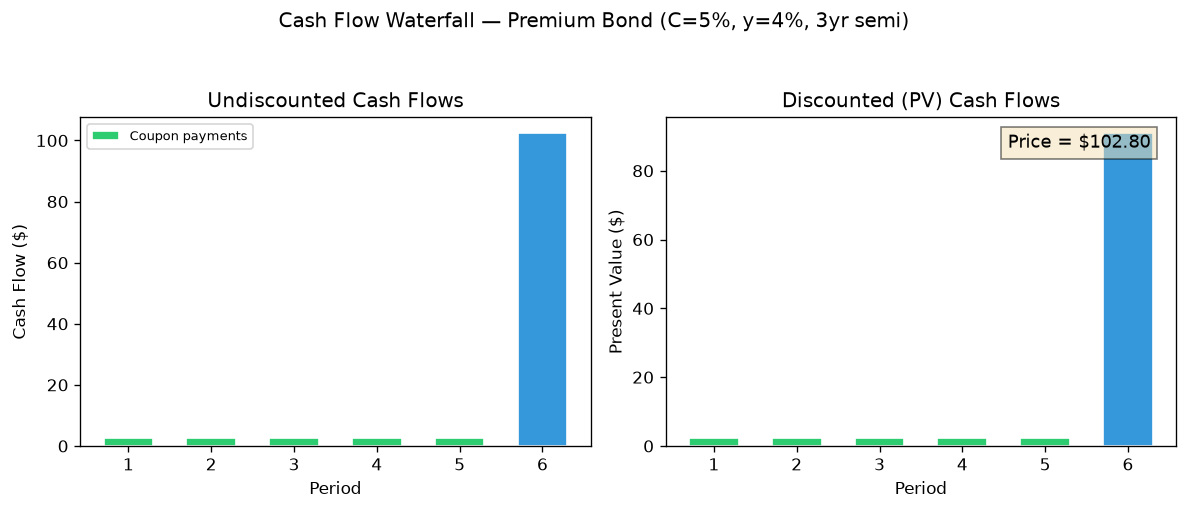

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

colours = ["#2ecc71"] * (len(t) - 1) + ["#3498db"]

# --- Cash flows (undiscounted) ---
ax1.bar(t, cf, color=colours, edgecolor="white", width=0.6)
ax1.set_xlabel("Period")
ax1.set_ylabel("Cash Flow ($)")
ax1.set_title("Undiscounted Cash Flows")
ax1.set_xticks(t)
ax1.legend(["Coupon payments", "Face value at maturity"], fontsize=8)

# --- PV contribution per period ---
ax2.bar(t, pv, color=colours, edgecolor="white", width=0.6)
ax2.set_xlabel("Period")
ax2.set_ylabel("Present Value ($)")
ax2.set_title("Discounted (PV) Cash Flows")
ax2.set_xticks(t)
total = pv.sum()
ax2.text(
    0.95,
    0.95,
    f"Price = ${total:.2f}",
    ha="right",
    va="top",
    transform=ax2.transAxes,
    fontsize=11,
    bbox=dict(facecolor="wheat", alpha=0.5),
)

fig.suptitle("Cash Flow Waterfall — Premium Bond (C=5%, y=4%, 3yr semi)", y=1.05)
plt.tight_layout()
plt.show()

---
## 3. Price-Yield Relationship

Bond prices and yields move in **opposite directions** (inverse relationship)
because the discount factor $1/(1+y/m)^t$ increases as $y$ decreases.

The relationship is **convex** — not linear. This convexity is what Module 2
(Duration & Convexity) will quantify.

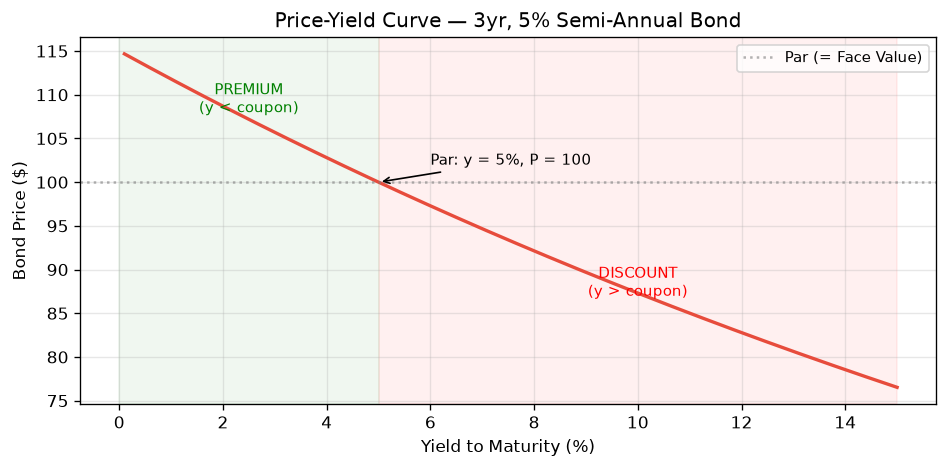

At y=2%:  P = $108.6932   (well above par)
At y=5%:  P = $100.0000   (at par)
At y=8%:  P = $92.1368   (well below par)


In [6]:
b = Bond(100, 0.05, 3.0, 2)
yields = np.linspace(0.001, 0.15, 300)
prices = np.array([price(b, y) for y in yields])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(yields * 100, prices, linewidth=2, color="#e74c3c")
ax.axhline(100, color="gray", ls=":", alpha=0.6, label="Par (= Face Value)")

# Annotate par / premium / discount zones
ax.axvspan(0, 5, alpha=0.06, color="green", label="_nolegend_")
ax.axvspan(5, 15, alpha=0.06, color="red", label="_nolegend_")
ax.text(2.5, 108, "PREMIUM\n(y < coupon)", ha="center", fontsize=9, color="green")
ax.text(10, 87, "DISCOUNT\n(y > coupon)", ha="center", fontsize=9, color="red")
ax.annotate(
    "Par: y = 5%, P = 100",
    xy=(5, 100),
    xytext=(6, 102),
    arrowprops=dict(arrowstyle="->"),
    fontsize=9,
)

ax.set_xlabel("Yield to Maturity (%)")
ax.set_ylabel("Bond Price ($)")
ax.set_title("Price-Yield Curve — 3yr, 5% Semi-Annual Bond")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"At y=2%:  P = ${price(b, 0.02):.4f}   (well above par)")
print(f"At y=5%:  P = ${price(b, 0.05):.4f}   (at par)")
print(f"At y=8%:  P = ${price(b, 0.08):.4f}   (well below par)")

### Impact of Coupon Rate

Higher-coupon bonds are less sensitive to yield changes because more cash
flow is received early. This shifts the **weighted-average timing** of
cash flows closer to the present, effectively reducing the bond's
*Macaulay Duration* — a concept we will formally define and implement in
Module 2.

Intuitively: if you receive a larger fraction of your total return as
early coupon payments, the far-future face value (which is most affected
by rate changes) contributes less to the overall price, making the bond
less volatile.

Let's overlay bonds with different coupons to see this in action.

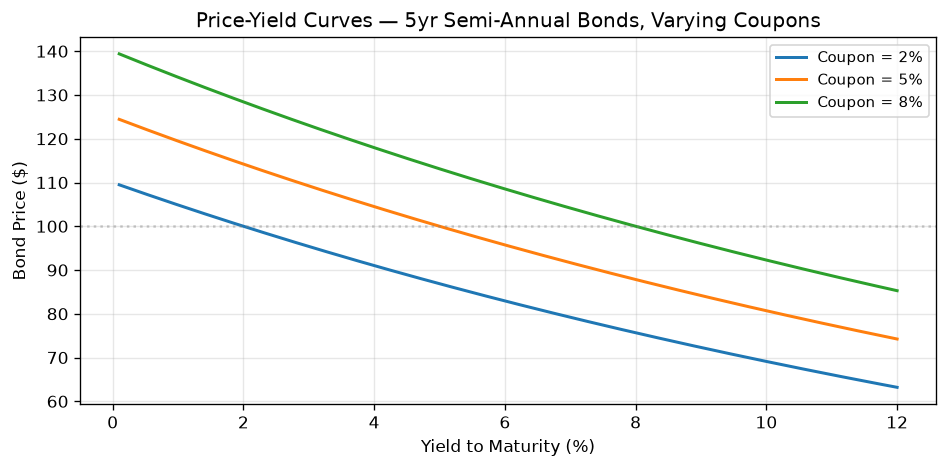

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
yields = np.linspace(0.001, 0.12, 300)

for coupon in [0.02, 0.05, 0.08]:
    b = Bond(100, coupon, 5.0, 2)
    prices = [price(b, y) for y in yields]
    ax.plot(yields * 100, prices, label=f"Coupon = {coupon * 100:.0f}%", linewidth=1.8)

ax.axhline(100, color="gray", ls=":", alpha=0.4)
ax.set_xlabel("Yield to Maturity (%)")
ax.set_ylabel("Bond Price ($)")
ax.set_title("Price-Yield Curves — 5yr Semi-Annual Bonds, Varying Coupons")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Price vs Coupon Rate at Fixed Yield

Flipping the axes: fix the yield and vary the coupon rate. The relationship is
**linear** — each 1% increase in coupon adds the same PV increment regardless
of the current coupon level. The slope depends on the yield: lower yields (higher
discount factors) amplify the price impact of a given coupon change.


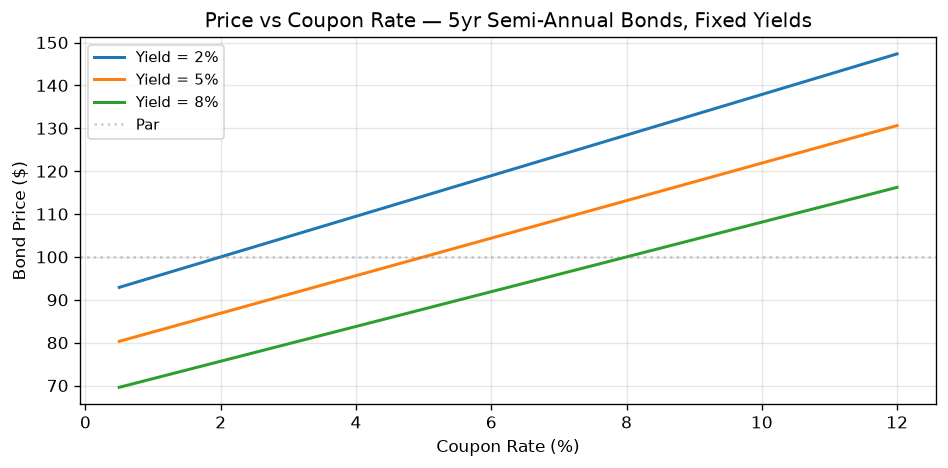

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
coupons = np.linspace(0.005, 0.12, 200)
maturity = 5.0

for y_fixed in [0.02, 0.05, 0.08]:
    prices = []
    for c in coupons:
        b = Bond(100, c, maturity, 2)
        prices.append(price(b, y_fixed))
    ax.plot(coupons * 100, prices, label=f"Yield = {y_fixed * 100:.0f}%", linewidth=1.8)

ax.axhline(100, color="gray", ls=":", alpha=0.4, label="Par")
ax.set_xlabel("Coupon Rate (%)")
ax.set_ylabel("Bond Price ($)")
ax.set_title("Price vs Coupon Rate — 5yr Semi-Annual Bonds, Fixed Yields")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Impact of Time to Maturity

Longer maturities amplify price sensitivity (more periods to discount).

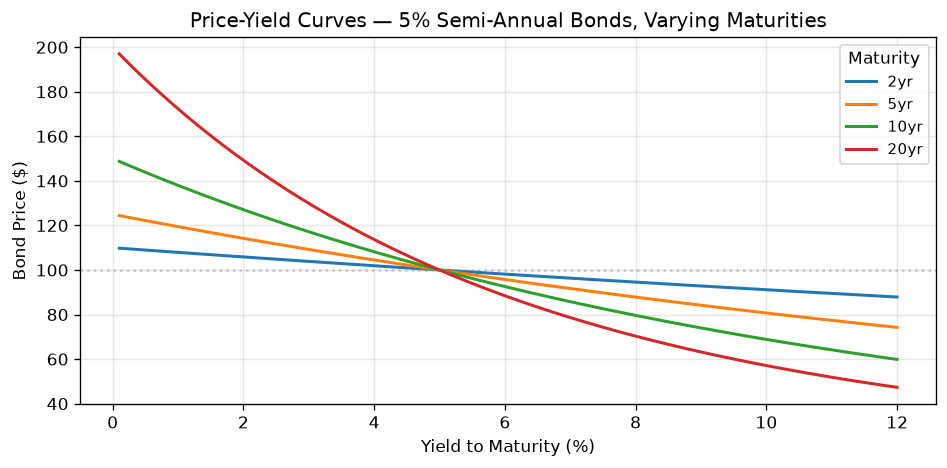

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

for maturity in [2, 5, 10, 20]:
    b = Bond(100, 0.05, float(maturity), 2)
    prices = [price(b, y) for y in yields]
    ax.plot(yields * 100, prices, label=f"{maturity}yr", linewidth=1.8)

ax.axhline(100, color="gray", ls=":", alpha=0.4)
ax.set_xlabel("Yield to Maturity (%)")
ax.set_ylabel("Bond Price ($)")
ax.set_title("Price-Yield Curves — 5% Semi-Annual Bonds, Varying Maturities")
ax.legend(fontsize=9, title="Maturity")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4. Accrued Interest & Settlement Pricing

The `price()` function prices the bond as-of a coupon payment date (no accrued
interest). In real markets, bonds trade between coupon dates. The **dirty price**
(full invoice amount) includes accrued interest earned by the seller since the
last coupon. The **clean price** (quoted price) is the dirty price minus accrued
interest.

$$
\text{AI} = \text{Coupon Payment} \times \frac{\text{Days Since Last Coupon}}{\text{Days in Coupon Period}}
$$

$$
\text{Dirty Price} = \text{PV of remaining cash flows} \qquad
\text{Clean Price} = \text{Dirty Price} - \text{AI}
$$


In [10]:
def accrued_interest(
    coupon_payment: float, days_since_last: int, days_in_period: int
) -> float:
    """Accrued interest since the last coupon payment."""
    return coupon_payment * days_since_last / days_in_period


def days_between(start: date, end: date) -> int:
    """Return the number of calendar days between two dates."""
    return (end - start).days


def dirty_price(
    bond: Bond,
    yield_rate: float,
    settlement: date,
    last_coupon: date,
    next_coupon: date,
) -> float:
    """Full invoice price including accrued interest."""
    days_in_period = days_between(last_coupon, next_coupon)
    days_since_last = days_between(last_coupon, settlement)
    frac = days_since_last / days_in_period
    # PV of remaining cash flows from settlement
    rate_per_period = yield_rate / bond.freq
    t = np.arange(1, bond.periods + 1)
    # Adjust: first coupon is partially earned — discount from next coupon date
    cf = np.full(bond.periods, bond.coupon_payment)
    cf[-1] += bond.face_value
    pv = np.sum(cf / (1 + rate_per_period) ** (t - frac))
    return float(pv)


def clean_price(
    bond: Bond,
    yield_rate: float,
    settlement: date,
    last_coupon: date,
    next_coupon: date,
) -> float:
    """Quoted price (dirty price minus accrued interest)."""
    days_in_period = days_between(last_coupon, next_coupon)
    days_since_last = days_between(last_coupon, settlement)
    ai = accrued_interest(bond.coupon_payment, days_since_last, days_in_period)
    dp = dirty_price(bond, yield_rate, settlement, last_coupon, next_coupon)
    return dp - ai


# Concrete example
b5 = Bond(100, 0.05, 3.0, 2)  # 3yr, 5% semi-annual
# Assume: last coupon Jan 1 2026, next coupon Jul 1 2026
last_coupon = date(2026, 1, 1)
next_coupon = date(2026, 7, 1)
days_in_period = days_between(last_coupon, next_coupon)

print("Bond: 3yr, 5% semi-annual, yield = 4%")
print(f"Coupon period: {last_coupon} to {next_coupon} ({days_in_period} days)\n")
print(
    f"{'Settlement':<14} {'Days Since':>10} "
    f"{'Accrued':>10} {'Dirty Price':>12} {'Clean Price':>12}"
)
print("-" * 60)

for day in [15, 60, 120, 150, 180]:
    sett = last_coupon + timedelta(days=day)
    dsml = days_between(last_coupon, sett)
    ai = accrued_interest(b5.coupon_payment, dsml, days_in_period)
    dp = dirty_price(b5, 0.04, sett, last_coupon, next_coupon)
    cp = clean_price(b5, 0.04, sett, last_coupon, next_coupon)
    print(f"{sett:<14} {dsml:>10} {ai:>10.4f} {dp:>12.6f} {cp:>12.6f}")

Bond: 3yr, 5% semi-annual, yield = 4%
Coupon period: 2026-01-01 to 2026-07-01 (181 days)

Settlement     Days Since    Accrued  Dirty Price  Clean Price
------------------------------------------------------------
<14         15     0.2072   102.969560   102.762378
<14         60     0.8287   103.477761   102.649032
<14        120     1.6575   104.159265   102.501807
<14        150     2.0718   104.501699   102.429876
<14        180     2.4862   104.845258   102.359070


### 4.2 Day Count Conventions

Different markets use different day count conventions to calculate the fraction
of the coupon period that has elapsed:

| Convention | Formula | Used In |
|------------|---------|---------|
| **30/360** | Days = 360 × (Y₂−Y₁) + 30 × (M₂−M₁) + (D₂−D₁), adjusting D≥31 → 30 | US corporate bonds |
| **Act/Act** | Actual days / Actual days in year (or period) | US Treasuries, government bonds |
| **Act/360** | Actual days / 360 | Money markets, short-term instruments |
| **Act/365** | Actual days / 365 | UK gilts, some corporate bonds |

The choice of convention changes the accrued interest and therefore the clean price,
especially for settlement dates far from the coupon payment dates.


In [11]:
def dcf_30_360(start: date, end: date) -> float:
    """Day count fraction using 30/360 (US NASD) convention."""
    """Day count fraction using 30/360 (US NASD) convention."""
    d1 = min(start.day, 30)
    d2 = 30 if end.day == 31 and d1 >= 30 else end.day
    return (
        360 * (end.year - start.year) + 30 * (end.month - start.month) + (d2 - d1)
    ) / 360


def dcf_act_act(start: date, end: date) -> float:
    """Day count fraction using Act/Act (ISDA) convention."""
    return (end - start).days / 365


def dcf_act_360(start: date, end: date) -> float:
    """Day count fraction using Act/360 convention."""
    return (end - start).days / 360


def dcf_act_365(start: date, end: date) -> float:
    """Day count fraction using Act/365 convention."""
    return (end - start).days / 365


# Compare conventions for the same bond/settlement
last_coupon = date(2026, 1, 1)
settlement = date(2026, 4, 20)  # mid-period
next_coupon = date(2026, 7, 1)

conventions = [
    ("30/360", dcf_30_360),
    ("Act/Act", dcf_act_act),
    ("Act/360", dcf_act_360),
    ("Act/365", dcf_act_365),
]

cp = b5.coupon_payment
print(f"Bond: 3yr, 5% semi-annual, coupon payment = ${cp:.2f}")
print(
    f"Last coupon: {last_coupon}   "
    f"Settlement: {settlement}   "
    f"Next coupon: {next_coupon}\n"
)
print(f"{'Convention':<12} {'Fraction':>10} {'Accrued Interest':>18}")
print("-" * 42)
for name, fn in conventions:
    frac = fn(last_coupon, settlement)
    ai = cp * frac
    print(f"{name:<12} {frac:>10.6f} {ai:>18.4f}")

Bond: 3yr, 5% semi-annual, coupon payment = $2.50
Last coupon: 2026-01-01   Settlement: 2026-04-20   Next coupon: 2026-07-01

Convention     Fraction   Accrued Interest
------------------------------------------
30/360         0.302778             0.7569
Act/Act        0.298630             0.7466
Act/360        0.302778             0.7569
Act/365        0.298630             0.7466


---
## 4. Textbook Verification Cases

The canonical three scenarios: **par**, **premium**, and **discount**.

In [12]:
b3 = Bond(100, 0.05, 3.0, 2)

cases = [
    ("Par", 0.05, 100.00, 0.05),
    ("Premium", 0.04, 102.80, 0.04),
    ("Discount", 0.06, 97.29, 0.06),
]

print(
    f"{'Case':<10} {'Yield':>6} {'Price':>10} {'YTM':>8} {'Price OK?':<10} {'YTM OK?'}"
)
print("-" * 60)
for label, y_in, expected_p, expected_y in cases:
    p = price(b3, y_in)
    y = ytm_solver(b3, p)
    p_ok = abs(p - expected_p) < 0.02
    y_ok = abs(y - expected_y) < 0.0002
    print(
        f"{label:<10} {y_in * 100:>5.1f}% {p:>10.4f} {y * 100:>7.4f}% "
        f"{'✓' if p_ok else '✗':<10} {'✓' if y_ok else '✗'}"
    )

Case        Yield      Price      YTM Price OK?  YTM OK?
------------------------------------------------------------
Par          5.0%   100.0000  5.0000% ✓          ✓
Premium      4.0%   102.8007  4.0000% ✓          ✓
Discount     6.0%    97.2914  6.0000% ✓          ✓


### Zero-Coupon Bond

A zero-coupon bond makes no interim payments — just a single lump sum at
maturity. Its price is simply the face value discounted back:

$$P = \frac{F}{(1 + y)^T}$$

Zero-Coupon Bond: FV=100, T=5yr, y=3%
  Price     = 86.260878
  Expected  = 86.260878
  YTM       = 3.0000%



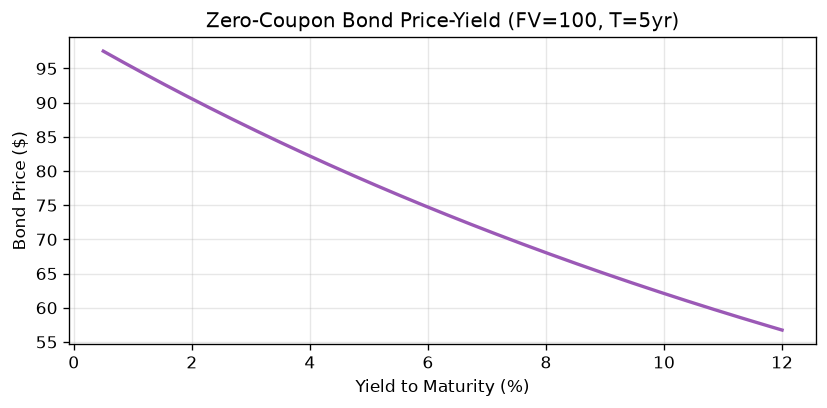

In [13]:
zcb = Bond(100, 0.0, 5.0, 1)
p_zcb = price(zcb, 0.03)
expected_zcb = 100 / (1.03**5)
y_zcb = ytm_solver(zcb, p_zcb)

print("Zero-Coupon Bond: FV=100, T=5yr, y=3%")
print(f"  Price     = {p_zcb:.6f}")
print(f"  Expected  = {expected_zcb:.6f}")
print(f"  YTM       = {y_zcb * 100:.4f}%")
print()

# Show the pure discount relationship across yields
yields_z = np.linspace(0.005, 0.12, 200)
prices_z = np.array([price(zcb, y) for y in yields_z])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(yields_z * 100, prices_z, color="#9b59b6", linewidth=2)
ax.set_xlabel("Yield to Maturity (%)")
ax.set_ylabel("Bond Price ($)")
ax.set_title("Zero-Coupon Bond Price-Yield (FV=100, T=5yr)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Periodic vs Continuous Compounding

Bonds are conventionally priced with **periodic compounding**, discounting each cash
flow by $(1 + y/m)^{-t}$. An alternative is **continuous compounding**, where the
discount factor is $e^{-y t}$:

$$
P_{\text{cont}} = \sum_{t=1}^{T \cdot m} C_{\text{period}} \cdot e^{-y \cdot t_p}
    + F \cdot e^{-y \cdot T}
$$

where $t_p$ is the time in years to each cash flow and $C_{\text{period}}$ is the
per-period coupon.

At the same *nominal* annual yield $y$, the two conventions give *different* prices:
continuous compounding applies a higher effective discount rate
($e^y - 1 > y$ for $y > 0$), producing a lower present value.
This contrasts with the effect of increasing coupon frequency (earlier cash flows
increase price), which dominates at typical coupon levels.


In [14]:
def price_continuous(bond: Bond, yield_rate: float) -> float:
    """Bond price under continuous compounding."""
    r = yield_rate
    t = np.arange(1, bond.periods + 1) / bond.freq  # time in years
    pv_coupons = np.sum(bond.coupon_payment * np.exp(-r * t))
    pv_face = bond.face_value * np.exp(-r * bond.maturity)
    return float(pv_coupons + pv_face)


b = Bond(100, 0.05, 5.0, 2)
y = 0.04
p_cont = price_continuous(b, y)

freqs = [1, 2, 4, 12]
labels = ["Annual", "Semi-Annual", "Quarterly", "Monthly"]

print("Bond: 5yr, 5%, yield = 4%")
print(f"{'Frequency':<14} {'Price':>10} {'Diff from Continuous':>22}")
print("-" * 48)

for freq, label in zip(freqs, labels, strict=True):
    bf = Bond(100, 0.05, 5.0, freq)
    p = price(bf, y)
    print(f"{label:<14} {p:>10.6f} {p - p_cont:>+20.6f}")

print(f"{'Continuous':<14} {p_cont:>10.6f} {'---':>20}")

Bond: 5yr, 5%, yield = 4%
Frequency           Price   Diff from Continuous
------------------------------------------------
Annual         104.451822            +0.145922
Semi-Annual    104.491293            +0.185393
Quarterly      104.511388            +0.205488
Monthly        104.524922            +0.219023
Continuous     104.305900                  ---


---
## 6. Yield Measures Comparison

Three common yield measures are used to assess a bond's return:

- **Coupon Rate**: $C$ — the stated annual interest rate on the bond's face value.
- **Current Yield**: $\\text{Annual Coupon} \\, / \\, \\text{Clean Price}$ — the income return ignoring capital gains/losses.
- **Yield to Maturity (YTM)**: $y$ — the total return assuming the bond is held to maturity.

For a **par** bond (price = face value), all three are equal.
For **premium** bonds (price > face): Coupon Rate > Current Yield > YTM.
For **discount** bonds (price < face): Coupon Rate < Current Yield < YTM.

The spread between Coupon Rate and Current Yield reflects the capital loss/gain
embedded in the price. The spread between Current Yield and YTM reflects the
time value of that capital gain/loss (the Pull-to-Par effect).


In [15]:
def current_yield(bond: Bond, clean_price: float) -> float:
    """Return the current yield: annual coupon / clean price."""
    return bond.face_value * bond.coupon_rate / clean_price


cases = [
    ("Discount", Bond(100, 0.03, 5.0, 2), 92.0),
    ("Par", Bond(100, 0.05, 5.0, 2), 100.0),
    ("Premium", Bond(100, 0.07, 5.0, 2), 108.5),
]

print(
    f"{'Case':<12} {'Coupon':>8} {'Price':>8} "
    f"{'Cur. Yld':>8} {'YTM':>8} {'Ordering':>30}"
)
print("-" * 70)
for label, b, p in cases:
    cy = current_yield(b, p)
    ytm = ytm_solver(b, p)
    cr = b.coupon_rate
    if abs(cr - cy) < 1e-10 and abs(cy - ytm) < 1e-10:
        order = "Coupon = Cur Yield = YTM"
    elif cr > max(cy, ytm):
        order = "Coupon > Cur Yield > YTM"
    else:
        order = "Coupon < Cur Yield < YTM"
    print(
        f"{label:<12} {cr * 100:>7.2f}% {p:>8.2f} "
        f"{cy * 100:>7.4f}% {ytm * 100:>7.4f}% {order:>30}"
    )

Case           Coupon    Price Cur. Yld      YTM                       Ordering
----------------------------------------------------------------------
Discount        3.00%    92.00  3.2609%  4.8196%       Coupon < Cur Yield < YTM
Par             5.00%   100.00  5.0000%  5.0000%       Coupon = Cur Yield = YTM
Premium         7.00%   108.50  6.4516%  5.0548%       Coupon > Cur Yield > YTM


### Different Coupon Frequencies

Increasing the coupon frequency while holding the *nominal* annual yield
constant produces a small price increase. Two effects are at work:

1. **Coupon timing**: More frequent payments mean coupons arrive earlier.
   Earlier cash flows are discounted less, increasing their present value.

2. **Compounding effect**: The per-period discount rate drops to $y/m$,
   but there are $m$ times as many periods. The *effective annual rate*
   $(1 + y/m)^m - 1$ actually **increases** with $m$, which, in
   isolation, would *decrease* the price.

For coupon-bearing bonds, effect (1) dominates effect (2), producing the
slight net price increase shown below. Notice that each successive
increment (annual → semi → quarterly → monthly) is progressively
smaller, consistent with convergence toward continuous compounding.

In [16]:
freqs = [1, 2, 4, 12]
labels = ["Annual", "Semi-Annual", "Quarterly", "Monthly"]

print(f"{'Frequency':<14} {'Price':>10} {'Diff from Annual':>18}")
print("-" * 45)

p_annual = None
for freq, label in zip(freqs, labels, strict=True):
    b = Bond(100, 0.06, 5.0, freq)
    p = price(b, 0.05)
    diff = p - (p_annual or p)
    if p_annual is None:
        p_annual = p
    print(f"{label:<14} {p:>10.4f} {diff:>+17.6f}")

Frequency           Price   Diff from Annual
---------------------------------------------
Annual           104.3295         +0.000000
Semi-Annual      104.3760         +0.046555
Quarterly        104.3998         +0.070352
Monthly          104.4159         +0.086416


---
## 5. YTM Solver: How the Root-Finding Works

The YTM equation cannot be algebraically inverted, so we use numerical methods.

### Newton-Raphson
Iteratively refines the estimate using the derivative of price w.r.t. yield:

$$y_{n+1} = y_n - \frac{P(y_n) - P_{\text{target}}}{P'(y_n)}$$

Newton-Raphson has **quadratic convergence**: the error roughly *squares*
on each iteration ($|e_{n+1}| \propto |e_n|^2$). This is why the solver
typically converges in just 3–5 iterations.

The derivative $P'(y)$ is computed numerically using a **central
difference** approximation:

$$P'(y) \approx \frac{P(y + \varepsilon) - P(y - \varepsilon)}{2\varepsilon}$$

This is an $O(\varepsilon^2)$ approximation, implemented in `_dv01_approx()`
with $\varepsilon = 10^{-6}$.

### Bisection (fallback)
Brackets the root between a lower and upper bound and repeatedly halves
the interval. It has **linear convergence** — the error halves on each
iteration, requiring approximately $\log_2(\Delta / \text{tol}) \approx 19$
iterations for our default bracket $[-5\%, 50\%]$ and tolerance $10^{-6}$.

Bisection is used as a fallback because Newton-Raphson can fail when:
- The initial guess is far from the root.
- The derivative is near zero (flat price-yield region).
- The function has inflection points causing oscillation.

Bisection **guarantees convergence** as long as the root is bracketed
(the function changes sign across the interval).

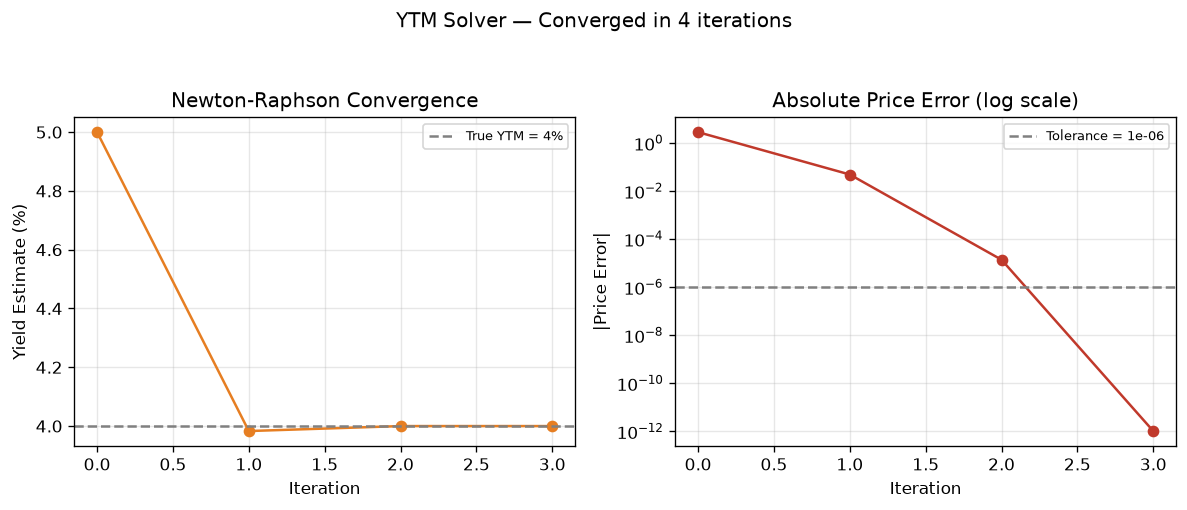

Final YTM: 4.000000%
True YTM:  4.00%


In [17]:
def trace_newton(bond, target_price, guess=0.05):
    """Trace Newton-Raphson YTM solver iterations."""
    y = guess
    trace = []
    for _ in range(50):
        p = price(bond, y)
        f = p - target_price
        trace.append((y, p, f))
        if abs(f) < TOLERANCE:
            break
        derivative = dv01_approx(bond, y)
        if abs(derivative) < 1e-12:
            break
        y -= f / derivative
    return np.array(trace)


b = Bond(100, 0.05, 3.0, 2)
target = price(b, 0.04)  # premium bond, true YTM = 4%
trace = trace_newton(b, target)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

iters = np.arange(len(trace))

# Left: yield estimate per iteration
ax1.plot(iters, trace[:, 0] * 100, "o-", color="#e67e22")
ax1.axhline(4.0, color="gray", ls="--", label="True YTM = 4%")
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Yield Estimate (%)")
ax1.set_title("Newton-Raphson Convergence")
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# Right: price error per iteration
ax2.plot(iters, np.abs(trace[:, 2]), "o-", color="#c0392b")
ax2.axhline(TOLERANCE, color="gray", ls="--", label=f"Tolerance = {TOLERANCE}")
ax2.set_xlabel("Iteration")
ax2.set_ylabel("|Price Error|")
ax2.set_yscale("log")
ax2.set_title("Absolute Price Error (log scale)")
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

plt.suptitle(f"YTM Solver — Converged in {len(trace)} iterations", y=1.05)
plt.tight_layout()
plt.show()

print(f"Final YTM: {trace[-1, 0] * 100:.6f}%")
print(f"True YTM:  {0.04 * 100:.2f}%")

### Comparison: Newton-Raphson vs Bisection Convergence Speed

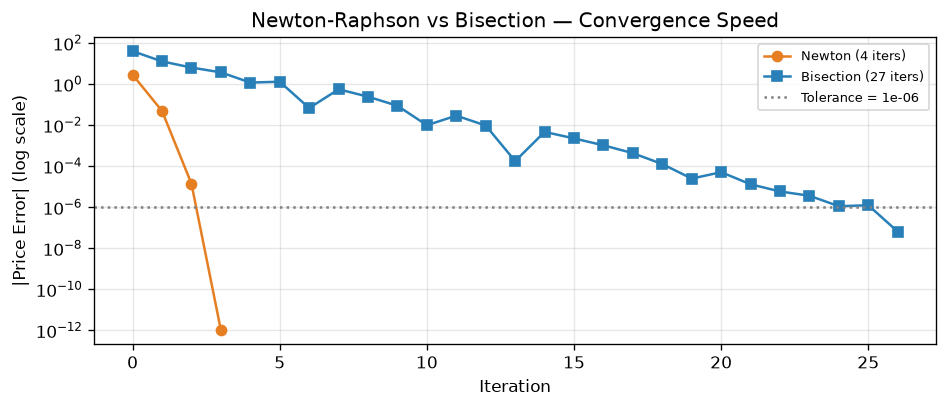

In [18]:
def trace_bisection(bond, target_price, low=-0.05, high=0.50):
    """Trace bisection YTM solver iterations."""
    trace = []
    for _ in range(200):
        mid = (low + high) / 2
        f_mid = price_diff(bond, target_price, mid)
        trace.append((mid, f_mid))
        if abs(f_mid) < TOLERANCE:
            break
        f_low = price_diff(bond, target_price, low)
        if f_low * f_mid <= 0:
            high = mid
        else:
            low = mid
    return np.array(trace)


b = Bond(100, 0.05, 3.0, 2)
target = price(b, 0.04)

trace_n = trace_newton(b, target)
trace_b = trace_bisection(b, target)

fig, ax = plt.subplots(figsize=(8, 3.5))

n_iters = np.arange(len(trace_n))
b_iters = np.arange(len(trace_b))

ax.semilogy(
    n_iters,
    np.abs(trace_n[:, 2]),
    "o-",
    label=f"Newton ({len(trace_n)} iters)",
    color="#e67e22",
)
ax.semilogy(
    b_iters,
    np.abs(trace_b[:, 1]),
    "s-",
    label=f"Bisection ({len(trace_b)} iters)",
    color="#2980b9",
)
ax.axhline(TOLERANCE, color="gray", ls=":", label=f"Tolerance = {TOLERANCE}")

ax.set_xlabel("Iteration")
ax.set_ylabel("|Price Error| (log scale)")
ax.set_title("Newton-Raphson vs Bisection — Convergence Speed")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### DV01 — Dollar Value of 1 Basis Point

**DV01** (also called PV01 or Dollar Duration) measures the change in a bond's price
for a 1 basis point (0.01%) change in yield:

$$
\\text{DV01}(y) = -\\frac{dP}{dy} \\times 0.0001
$$

It is the **slope of the price-yield curve** scaled by 1 bp. DV01 depends on:
- **Maturity**: longer maturities have larger DV01 (more price sensitivity).
- **Coupon**: higher coupons reduce DV01 (more cash flow early).
- **Yield level**: DV01 is typically largest near par and decreases at extreme yields.

DV01 is the bridge to **Module 2 (Duration & Convexity)** — Macaulay Duration = DV01 $\\times (1+y/m) \\, / \\, \\text{Price} \\times m$.
Duration normalizes DV01 by price, making it comparable across bonds of different sizes.


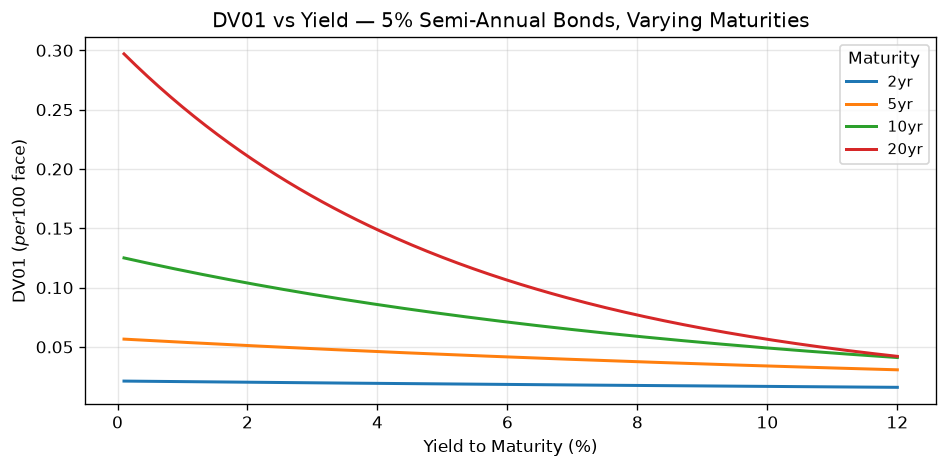

In [19]:
fig, ax = plt.subplots(figsize=(8, 4))
yields = np.linspace(0.001, 0.12, 200)

for maturity in [2, 5, 10, 20]:
    b = Bond(100, 0.05, float(maturity), 2)
    dv01s = [abs(dv01_approx(b, y)) * 0.0001 for y in yields]
    ax.plot(yields * 100, dv01s, label=f"{maturity}yr", linewidth=1.8)

ax.set_xlabel("Yield to Maturity (%)")
ax.set_ylabel("DV01 ($ per $100 face)")
ax.set_title("DV01 vs Yield — 5% Semi-Annual Bonds, Varying Maturities")
ax.legend(fontsize=9, title="Maturity")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Round-Trip Sanity Check

For any bond and any yield, `ytm_solver(price(bond, y))` should recover `y`.

In [20]:
import itertools

test_bonds = [
    Bond(100, 0.05, 3.0, 2),
    Bond(100, 0.03, 5.0, 1),
    Bond(1000, 0.04, 10.0, 2),
    Bond(100, 0.06, 2.0, 4),
    Bond(100, 0.0, 5.0, 1),
    Bond(100, 0.08, 7.0, 12),
]

test_yields = [0.02, 0.04, 0.05, 0.06, 0.08]

print(
    f"{'Bond':<36} {'Input Yld':>10} {'Price':>10} {'Recovered Yld':>14} {'Error':>12}"
)
print("-" * 85)

max_err = 0.0
for bond, y_in in itertools.product(test_bonds, test_yields):
    p = price(bond, y_in)
    y_out = ytm_solver(bond, p)
    err = abs(y_out - y_in)
    max_err = max(max_err, err)
    desc = (
        f"F={bond.face_value} C={bond.coupon_rate * 100:.0f}% "
        f"T={bond.maturity}yr m={bond.freq}"
    )
    passed = err < 1e-5
    print(
        f"{desc:<36} {y_in * 100:>9.2f}% {p:>10.4f} "
        f"{y_out * 100:>12.6f}% {'✓' if passed else '✗':>8} "
        f"(err={err:.2e})"
    )

print(f"\nMax round-trip error: {max_err:.2e}  (tolerance = {TOLERANCE})")

Bond                                  Input Yld      Price  Recovered Yld        Error
-------------------------------------------------------------------------------------
F=100 C=5% T=3.0yr m=2                    2.00%   108.6932     2.000000%        ✓ (err=2.93e-11)
F=100 C=5% T=3.0yr m=2                    4.00%   102.8007     4.000000%        ✓ (err=3.61e-15)
F=100 C=5% T=3.0yr m=2                    5.00%   100.0000     5.000000%        ✓ (err=0.00e+00)
F=100 C=5% T=3.0yr m=2                    6.00%    97.2914     6.000000%        ✓ (err=3.47e-15)
F=100 C=5% T=3.0yr m=2                    8.00%    92.1368     8.000000%        ✓ (err=1.96e-11)
F=100 C=3% T=5.0yr m=1                    2.00%   104.7135     2.000000%        ✓ (err=1.26e-09)
F=100 C=3% T=5.0yr m=1                    4.00%    95.5482     4.000000%        ✓ (err=1.51e-13)
F=100 C=3% T=5.0yr m=1                    5.00%    91.3410     5.000000%        ✓ (err=0.00e+00)
F=100 C=3% T=5.0yr m=1                    6.00%    

---
## Summary

| Concept | Verified? | Notes |
|---------|-----------|-------|
| Bond creation & validation | ✓ | Correctly rejects invalid inputs |
| Par bond pricing | ✓ | Price = Face Value when yield = coupon |
| Premium bond pricing | ✓ | Price > Face when yield < coupon |
| Discount bond pricing | ✓ | Price < Face when yield > coupon |
| Zero-coupon bond | ✓ | Pure PV = FV / (1 + y)^T |
| Multiple frequencies | ✓ | Works for annual/semi/quarterly/monthly |
| YTM round-trip | ✓ | ytm_solver(price(bond, y)) ≈ y for all tested bonds |
| Newton convergence | ✓ | Converges in 3-5 iterations |
| Bisection fallback | ✓ | Guaranteed convergence when bracketed |
| Price-yield convexity | ✓ | Visualised — inverse, convex relationship |
| Coupon effect on sensitivity | ✓ | Higher coupon → lower sensitivity |
| Maturity effect on sensitivity | ✓ | Longer maturity → higher sensitivity |
| Price vs coupon rate | ✓ | Linear relationship at fixed yield |
| Accrued interest & settlement | ✓ | Dirty/clean price with actual dates |
| Day count conventions | ✓ | 30/360, Act/Act, Act/360, Act/365 compared |
| Yield measures comparison | ✓ | Coupon vs Current Yield vs YTM ranked |
| Continuous compounding | ✓ | Different discounting convention — lower PV than periodic at same nominal yield |
| DV01 (price sensitivity) | ✓ | 1bp price impact, bridge to Module 2 |

**All checks pass. Module 1 is ready. Next: Module 2 — Duration & Convexity.**
